playground is to work on current issues and testing new functionalities with newest version of 2d_combined_playground.py

current issues:
- traditional spec image looks really weird when testing in .py file
- rendering breaks when trying to use new_utils.axis_labels() in non_rgb_iteration()

new functionality:
- adding in non-rgb line graph code

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker

import utils

import io
import helper_utils
import nist_helper
import re
import nist_codes
import numpy as np
import new_utils


import os
import random
import csv

import plot_funcs

from scipy.signal import find_peaks

import matplotlib

import matplotlib.patheffects as pe


In [2]:
# Shared Values
Y_TITLE = 'Intensity'
X_TITLE = 'Wavelength (nm)'
COLOUR = 'white'
BG = 'black'
X_MIN = 400
X_MAX = 750
FIG_WIDTH = 15
DPI = 600

# Traditional Plot Values
FIG_HEIGHT_BASE = 3.0
FIG_SIZE = (FIG_WIDTH, FIG_HEIGHT_BASE)
MIN_NEEDLE_WIDTH = 0.1
MAX_NEEDLE_WIDTH = 0.3
MAX_Y_SCALE = 0.75
NEEDLE_POWER_SHAPE = 4
LABEL_NORM_INT = 0.20
GLOW_WIDTH_MULT = 1.3

# Dynamic Height Values (overflow section)
fig_height_overflow_scale = 9.0

# Normalised-Specific Values
NORM_PROM_PERC = 0.15
NORM_MIN_BRIGHT = 0.01
NORM_GLOW_ALPHA = 0
NORM_PEAK_EMPHASIS = 1.1
NORM_PEAK_LABEL_POSN = 0.75

# "Default" Values (i.e. for not normalised)
DEFAULT_PROM_PERC = 0.08    # also used by "other" plots
DEFAULT_MIN_BRIGHT = 0.1    # also used by "other" plots
DEFAULT_GLOW_ALPHA = 0.35
DEFAULT_PEAK_EMPHASIS = 1.4
DEFAULT_PEAK_LABEL_POSN = 0.77

# Other Plot Values
fig_size = (15,6)
#prominence = 0.08       # changed from 0.12
#min_bright = 0.1
min_alpha = 0.1
min_alpha_scatter = 0.2
base_marker_size = 5
max_marker_size_factor = 95
gamma_factor = 0.8
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be
reverse_x = True
plot_type = None
show_grid = True


major_locator = ticker.MultipleLocator(50)
minor_locator = ticker.MultipleLocator(10)


detection_col = '_raw_int'
int_col = '_adj_int'

lambda_tokens = ["nm", "wavelength", "wavelength_nm", "lambda", "lambda_nm", "wl", "wl_nm", "Observed", "Observed Wavelength", "obs", "wave", "w"]

int_tokens =["Grey Val", "grey val", "gray val", "grayscale", "gray value", "intensity", "signal", "counts", "value", "int", "rel. int.", "grey", "Rel. Int.", "Relative Intensity", "Rel Int", "Intensity", "A", "Aki", "gA", "gf", "weighted f", "f", "Intensity/Counts", 'rel', 'count', 'flux', 'grey value', 'i']


In [ ]:


try:
    import nist_helper
    descriptor_tokens = [t.lower() for t in getattr(nist_helper, "NIST_DESCRIPTORS", [])]
except Exception:
    nist_helper = None
    descriptor_tokens = []


def plot_spec(
    data_df,
    nm_col=None,
    int_col=None,
    prominence_percentage=0.12,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    fig_size=utils.FIG_SIZE,
    min_brightness=0.1,
    save_path=None,
    min_needle_max_width_nm=utils.MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=utils.MAX_NEEDLE_WIDTH,
    needle_shape_power=utils.NEEDLE_POWER_SHAPE,
    glow_width_multiplier=utils.GLOW_WIDTH_MULT,
    glow_alpha=0.35,
    dpi=utils.DPI,
    mode='dark',
    peak_label_y_position=None,
    max_needle_y_scale=0,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=utils.LABEL_NORM_INT,
    scale_mode='auto',
    title=None,
    random_title=None,
):
    
    if show_peak_labels is False:
        max_needle_y_scale = 1.0
    else:
        max_needle_y_scale = utils.MAX_Y_SCALE

    
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = utils.resolve_column(data_df, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = utils.resolve_column(data_df, utils.int_tokens, "intensity",)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # run NIST detector
    has_any_nist, _nist_diag = nist_codes.detect_nist_values(df_plot_data[int_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        min_brightness = utils.DEFAULT_MIN_BRIGHT
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = utils.DEFAULT_PROM_PERC
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')

        # Apply user-chosen scale mode for non-NIST data
        if scale_mode == 'normalize':
            min_brightness = utils.NORM_MIN_BRIGHT
            glow_alpha = utils.NORM_GLOW_ALPHA
            prominence_percentage = utils.NORM_PROM_PERC
            peak_label_y_position = utils.NORM_PEAK_LABEL_POSN
        elif scale_mode == 'raw':
            min_brightness = utils.DEFAULT_MIN_BRIGHT
            glow_alpha = utils.DEFAULT_GLOW_ALPHA
            prominence_percentage = utils.DEFAULT_PROM_PERC
            peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN

        # parse NIST-style cells
    parsed_intensity = df_plot_data[int_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    detection_col = '_raw_int'
    int_col = '_adj_int'

    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if scale_mode=='raw':
            prominence_percentage = utils.DEFAULT_PROM_PERC
        if scale_mode == 'normalize':
            prominence_percentage = utils.NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[int_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    init_peak_label_positon = peak_label_y_position

    if show_peak_labels is True:
        try:
            label_ys = utils.compute_label_positions(
                peak_nms,
                intensities=peak_ints,
                base_y=init_peak_label_positon,
                min_sep_nm=0.4,
                y_step=0.08,
                method="prefer_stronger_top",
                max_y=0.90,
            )
        except Exception:
            label_ys = [init_peak_label_positon] * len(peaks)

        if label_ys:
            max_label_y = max(label_ys)
            overflow = max(0, max_label_y - init_peak_label_positon)
            print("\noverflow:", overflow)
            print("o.g. peak label y pos'n:", init_peak_label_positon)
            if overflow > 0:
                new_height = utils.FIG_HEIGHT_BASE + overflow * utils.fig_height_overflow_scale
                fig_size = (fig_size[0], new_height)
                new_fig_height = new_height
            
                current_needle_height_in = max_needle_y_scale * new_height
                new_needle_height = (max_needle_y_scale * utils.FIG_HEIGHT_BASE) / new_height 
                max_needle_y_scale = new_needle_height
                
                new_peak_y_posn = (peak_label_y_position * utils.FIG_HEIGHT_BASE) / new_height
                peak_label_y_position = new_peak_y_posn
                
                print("needle height goal:", new_needle_height, "\n \t inches:", new_needle_height*new_height)
                print("current needle height (in):", current_needle_height_in)
                
                print("height:", new_height, "max label y:", max_label_y)
                print("\npeak label y pos'n goal:", new_peak_y_posn, "\nnew fig height:", new_fig_height)
                    
            else:
                print("Labels fit — no expansion needed")
                max_needle_y_scale = max_needle_y_scale
                print("peak label y pos'n:", peak_label_y_position)
        else:
            max_needle_y_scale = max_needle_y_scale
            print("No labels on this spectrum")
        
        print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")


        try:
            label_ys = utils.compute_label_positions(
                peak_nms,
                intensities=peak_ints,
                base_y=peak_label_y_position,   # now uses updated value
                min_sep_nm=0.4,
                y_step=0.08,
                method="prefer_stronger_top",
                max_y=0.90,
            )
        except Exception:
            label_ys = [peak_label_y_position] * len(peaks)

        print("\n new peak label pos'n:", peak_label_y_position)


    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    ax.set_ylim(0,1)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or scale_mode == 'raw':
            _peak_emphasis = utils.DEFAULT_PEAK_EMPHASIS
            min_brightness = utils.DEFAULT_MIN_BRIGHT
        elif scale_mode == 'normalize':
            _peak_emphasis = utils.NORM_PEAK_EMPHASIS
            min_brightness = utils.NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        colored_rgb = (
            base_rgb[0] * final_int_scale,
            base_rgb[1] * final_int_scale,
            base_rgb[2] * final_int_scale,
        )

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=colored_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=colored_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or scale_mode == 'raw':
        pad = 15
    else:
        pad = 10
    
    # Title logic: custom > random fallback > skip
    if title and str(title).strip():
        plt.title(str(title).strip(), color=text_color, y=1.0, pad=pad)
    if random_title:
        plt.title(utils.generate_random_title(), color=text_color, y=1.0, pad=pad)
    # else: no title at all

    # Save the plot if a save_path is provided
    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    return fig

In [ ]:
def plot_trad(
    df_plot_data,
    scale_mode = 'auto',
    show_peak_labels = True,
    nm_col = None,
    int_col = None,
    save_path = None,
    prominence_percentage=0,     
    fig_size=FIG_SIZE,
    min_brightness=0,
    peak_wavelengths=None,
    x_min=X_MIN,
    x_max=X_MAX,
    min_needle_max_width_nm=utils.MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=utils.MAX_NEEDLE_WIDTH,
    needle_shape_power=utils.NEEDLE_POWER_SHAPE,
    glow_width_multiplier=utils.GLOW_WIDTH_MULT,
    apply_descriptor_adjustments=False,
    glow_alpha=0,
    dpi=DPI,
    peak_label_y_position=0,
    force_nist = None,
    label_min_norm_int=LABEL_NORM_INT,
    subplots_adjust_top = 0.90,
    max_needle_y = MAX_Y_SCALE,
    fig_height_overflow_scale = fig_height_overflow_scale,
    fig_height_base = FIG_HEIGHT_BASE,
):

    if show_peak_labels is False:           #new block
        max_needle_y = 0.98
    else:
        max_needle_y = MAX_Y_SCALE

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    new_utils.trad_spec_labels(fig=fig, ax=ax, x_min=x_min, x_max=x_max,)


    # run NIST detector         #new block
    if nm_col is None:
        nm_col = utils.resolve_column(df_plot_data, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = utils.resolve_column(df_plot_data, utils.int_tokens, "intensity",)

        # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = df_plot_data.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    has_any_nist, _nist_diag = nist_codes.detect_nist_values(df_plot_data[int_col], force_nist=force_nist)


    if has_any_nist:
        scale_mode = None
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)        #new line
        min_brightness = helper_utils.DEFAULT_MIN_BRIGHT
        glow_alpha = helper_utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = helper_utils.DEFAULT_PROM_PERC
        peak_label_y_position = helper_utils.DEFAULT_PEAK_LABEL_POSN
    else:
        if scale_mode == 'raw':
            glow_alpha = helper_utils.DEFAULT_GLOW_ALPHA
            peak_label_y_position = helper_utils.DEFAULT_PEAK_LABEL_POSN
        elif scale_mode == 'normalize':
            glow_alpha = helper_utils.NORM_GLOW_ALPHA
            peak_label_y_position = helper_utils.NORM_PEAK_LABEL_POSN

    parsed_intensity = df_plot_data[int_col].apply(nist_codes.parse_nist_intensity)         #new block
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range



    # --- Peak Detection ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if scale_mode=='raw':
            prominence_percentage = utils.DEFAULT_PROM_PERC
        if scale_mode == 'normalize':
            prominence_percentage = utils.NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[int_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    init_peak_label_y_posn = peak_label_y_position

    if show_peak_labels is True:        #new cond'l
        try:
            label_ys = helper_utils.compute_label_positions(
                peak_nms,
                intensities=peak_ints,
                base_y=init_peak_label_y_posn,
                min_sep_nm=0.6,
                y_step=0.04,
                method="prefer_stronger_top",
                max_y=0.90,
            )
        except Exception:
            label_ys = [init_peak_label_y_posn] * len(peaks)

        if label_ys:
            max_label_y = max(label_ys)
            overflow = max(0, max_label_y - init_peak_label_y_posn)
            print("\noverflow:", overflow)
            print("o.g. peak label y pos'n:", init_peak_label_y_posn)
            if overflow > 0:
                new_height = fig_height_base + overflow * fig_height_overflow_scale
                new_fig_height = new_height
                fig.set_figheight(new_height)
                current_needle_height_in = max_needle_y * new_height
                new_needle_height = (max_needle_y * fig_height_base) / new_height 
                max_needle_y_scale = new_needle_height
                new_peak_y_posn = (init_peak_label_y_posn * fig_height_base) / new_height
                peak_label_y_position = new_peak_y_posn
                
                print("needle height goal:", new_needle_height, "\n \t inches:", new_needle_height*new_height)
                print("current needle height (in):", current_needle_height_in)
                print("height:", new_height, "max label y:", max_label_y)
                print("\npeak label y pos'n goal:", new_peak_y_posn, "\nnew fig height:", new_fig_height,) 
                    
            else:
                print("Labels fit — no expansion needed")
                max_needle_y_scale = max_needle_y
                print("peak label y pos'n:", peak_label_y_position)
        else:
            max_needle_y_scale = max_needle_y
            print("No labels on this spectrum")
        
        print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")


        try:
            label_ys = helper_utils.compute_label_positions(
                peak_nms,
                intensities=peak_ints,
                base_y=peak_label_y_position,   # now uses updated value
                min_sep_nm=0.4,
                y_step=0.08,
                method="prefer_stronger_top",
                max_y=0.90,
            )
        except Exception:
            label_ys = [peak_label_y_position] * len(peaks)

        print("\n new peak label pos'n:", peak_label_y_position)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = helper_utils.rgb(_nm)
        _final_scale = new_utils.final_scale(min_brightness, _ni)
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = new_utils.left_x(_nm, _bg_widths)
        _x_right = new_utils.right_x(_nm, _bg_widths)
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']
        base_rgb = helper_utils.rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or scale_mode == 'raw':   
            _peak_emphasis = helper_utils.DEFAULT_PEAK_EMPHASIS
            min_brightness = helper_utils.DEFAULT_MIN_BRIGHT
        elif scale_mode == 'normalize':
            _peak_emphasis = helper_utils.NORM_PEAK_EMPHASIS
            min_brightness = helper_utils.NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)
        color_rgb = new_utils.colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity
        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)

        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        
        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render))

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = new_utils.left_x(peak_nm, glow_current_widths_nm)
        glow_x_right = new_utils.right_x(peak_nm, glow_current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = new_utils.dynamic_prominence(scaled_max_width_nm, width_profile_factor)
        x_left = new_utils.left_x(peak_nm, current_widths_nm)
        x_right = new_utils.right_x(peak_nm, current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or scale_mode == 'raw':     # scale_mode == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    if scale_mode is not None:
        plt.title(f'{scale_mode.capitalize()} Emission Spectrum Visualization', color=helper_utils.COLOUR, y=0.98, pad=pad)
    else:
        plt.title('Emission Spectrum Visualization', color=helper_utils.COLOUR, y=0.98, pad=pad)
    plt.subplots_adjust(top=subplots_adjust_top)

    print("\nDEBUG: fig height = ", fig.get_figheight(), "\n current needle height = ", current_peak_render_height)


    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)


    return fig, ax

In [10]:

HE_SHEET = "he test.xlsx"
NIST_SHEET = "oxygen nist 2.xlsx"




HE_DF = pd.read_excel(HE_SHEET)
NIST_DF = pd.read_excel(NIST_SHEET)

global df
df = NIST_DF


DEBUG: trad_spec_labels
method prefer_stronger_top
n 4
base y 0.77
step 0.04
result[idx] 0.77
result[idx] 0.81
result[idx] 0.85
result[idx] 0.89
method prefer_stronger_top
n 4
base y 0.77
step 0.04
result[idx] 0.77
result[idx] 0.81
result[idx] 0.85
result[idx] 0.89
method prefer_stronger_top
n 38
base y 0.77
step 0.0035135135135135136
result[idx] 0.77
result[idx] 0.7735135135135135
result[idx] 0.7770270270270271
result[idx] 0.7805405405405406
result[idx] 0.784054054054054
result[idx] 0.7875675675675676
result[idx] 0.7910810810810811
result[idx] 0.7945945945945946
result[idx] 0.7981081081081082
result[idx] 0.8016216216216216
result[idx] 0.8051351351351351
result[idx] 0.8086486486486487
result[idx] 0.8121621621621622
result[idx] 0.8156756756756757
result[idx] 0.8191891891891893
result[idx] 0.8227027027027027
result[idx] 0.8262162162162162
result[idx] 0.8297297297297297
result[idx] 0.8332432432432433
result[idx] 0.8367567567567568
result[idx] 0.8402702702702702
result[idx] 0.8437837837837

(<Figure size 9000x2502 with 1 Axes>,
 <Axes: title={'center': 'Emission Spectrum Visualization'}, xlabel='Wavelength (nm)'>)

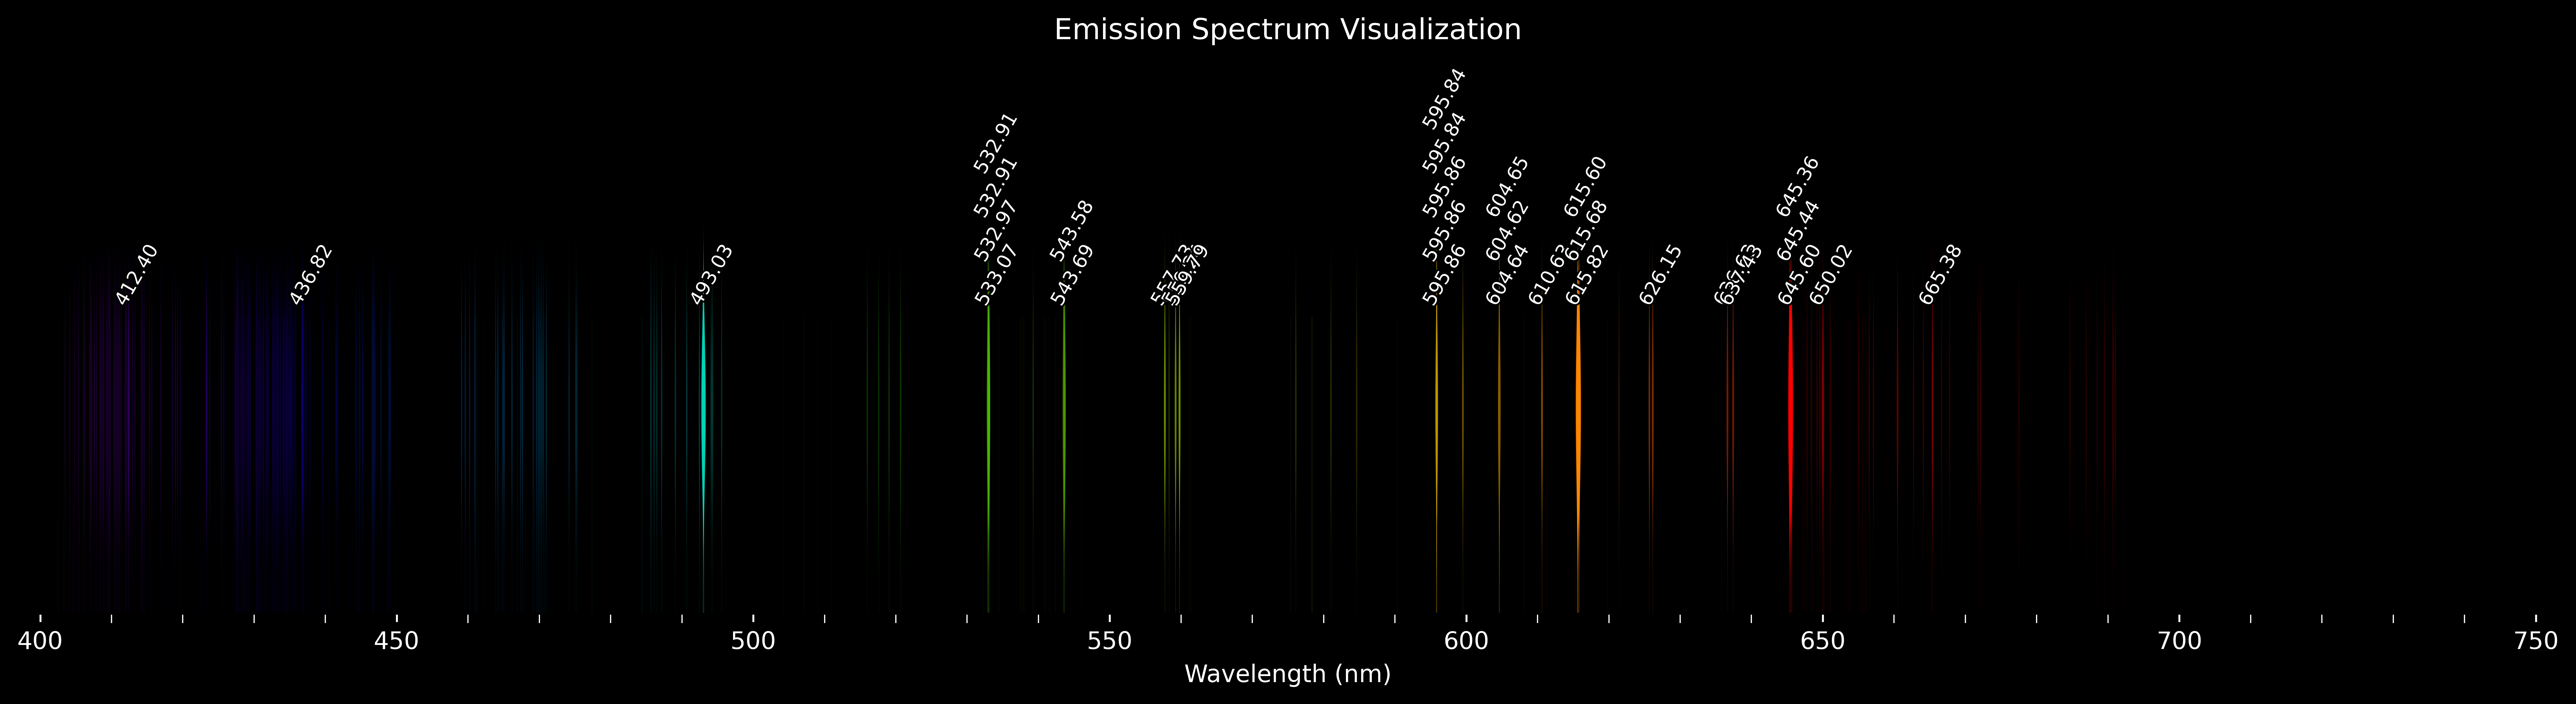

In [9]:
plot_trad(NIST_DF)

NIST Destriptors Detected. Preparing NIST Rendering.

overflow: 0.13
o.g. peak label y pos'n: 0.77
needle height goal: 0.539568345323741 
 	 inches: 2.25
current needle height (in): 3.1275
height: 4.17 max label y: 0.9

peak label y pos'n goal: 0.5539568345323741 
new fig height: 4.17
DEBUG: max_label_y = 0.9

 new peak label pos'n: 0.5539568345323741


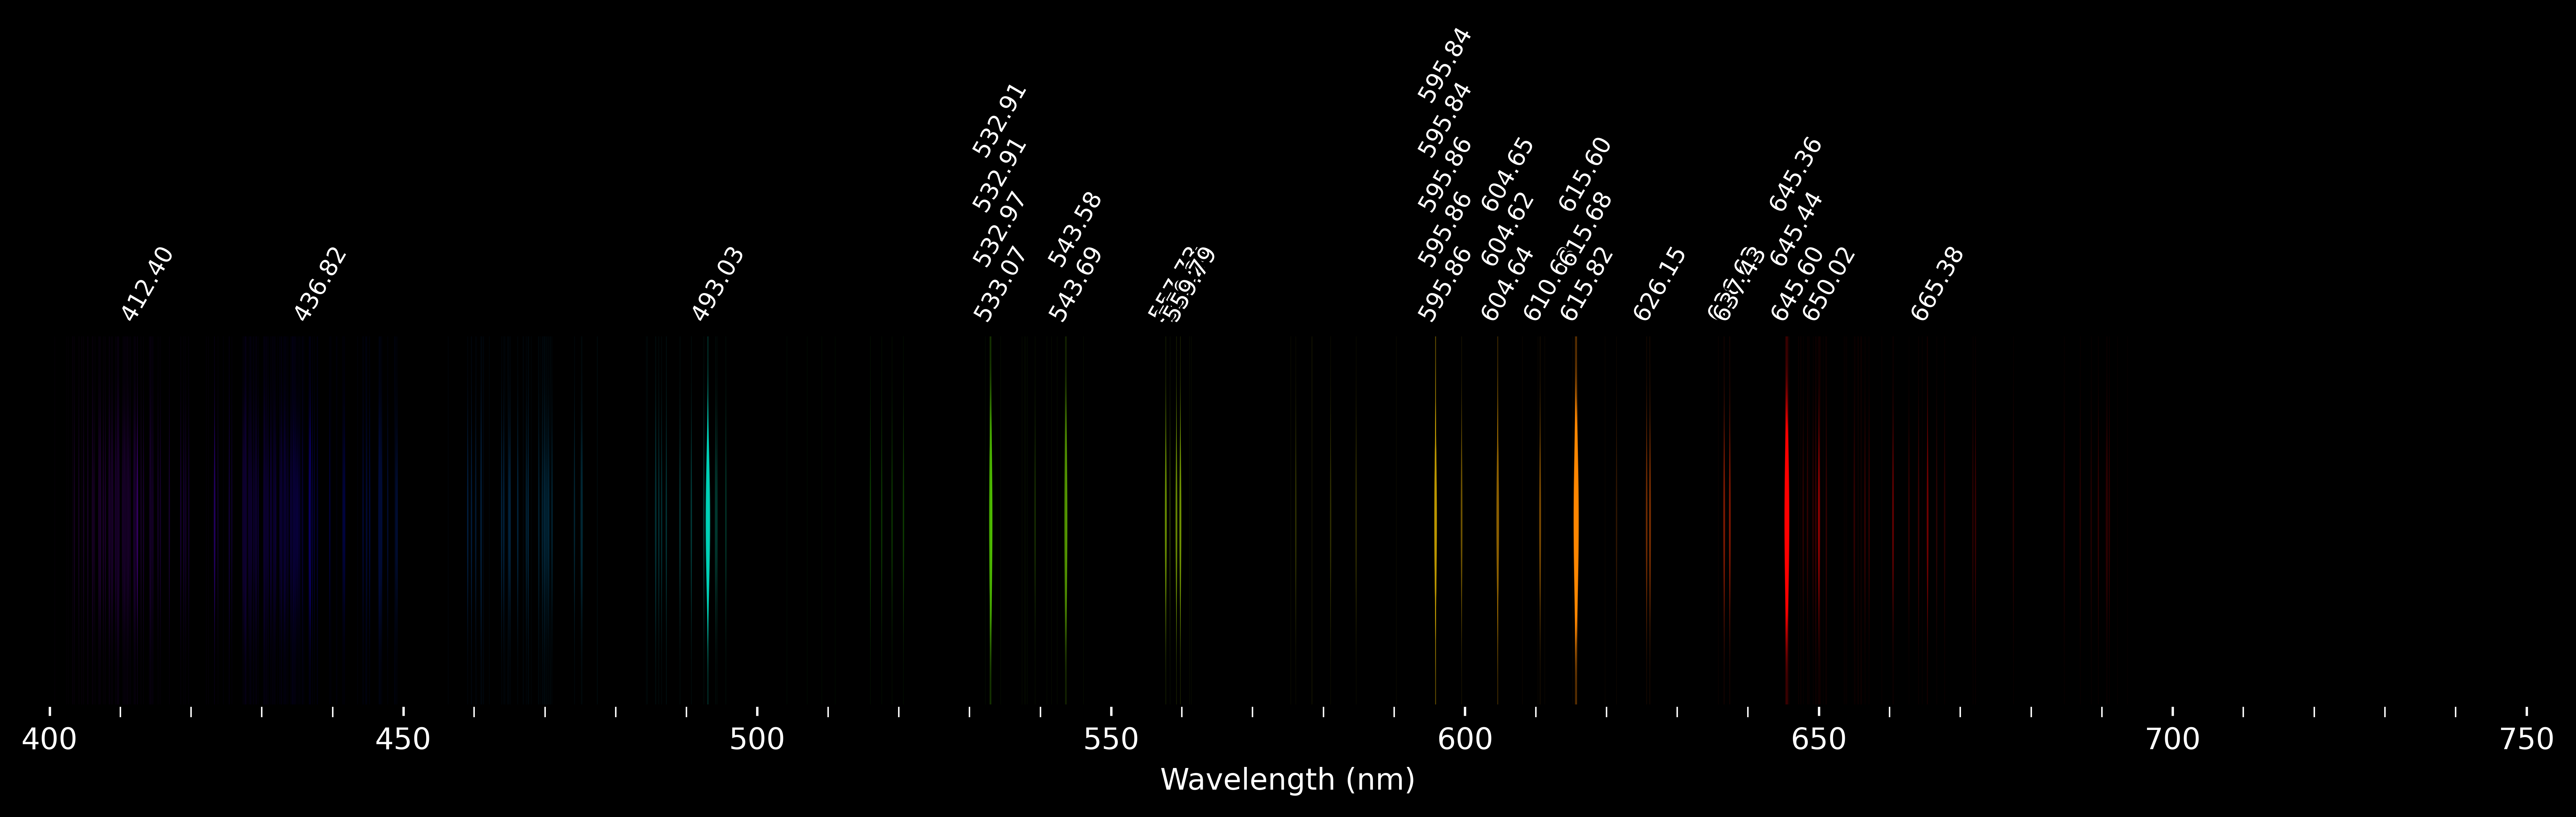

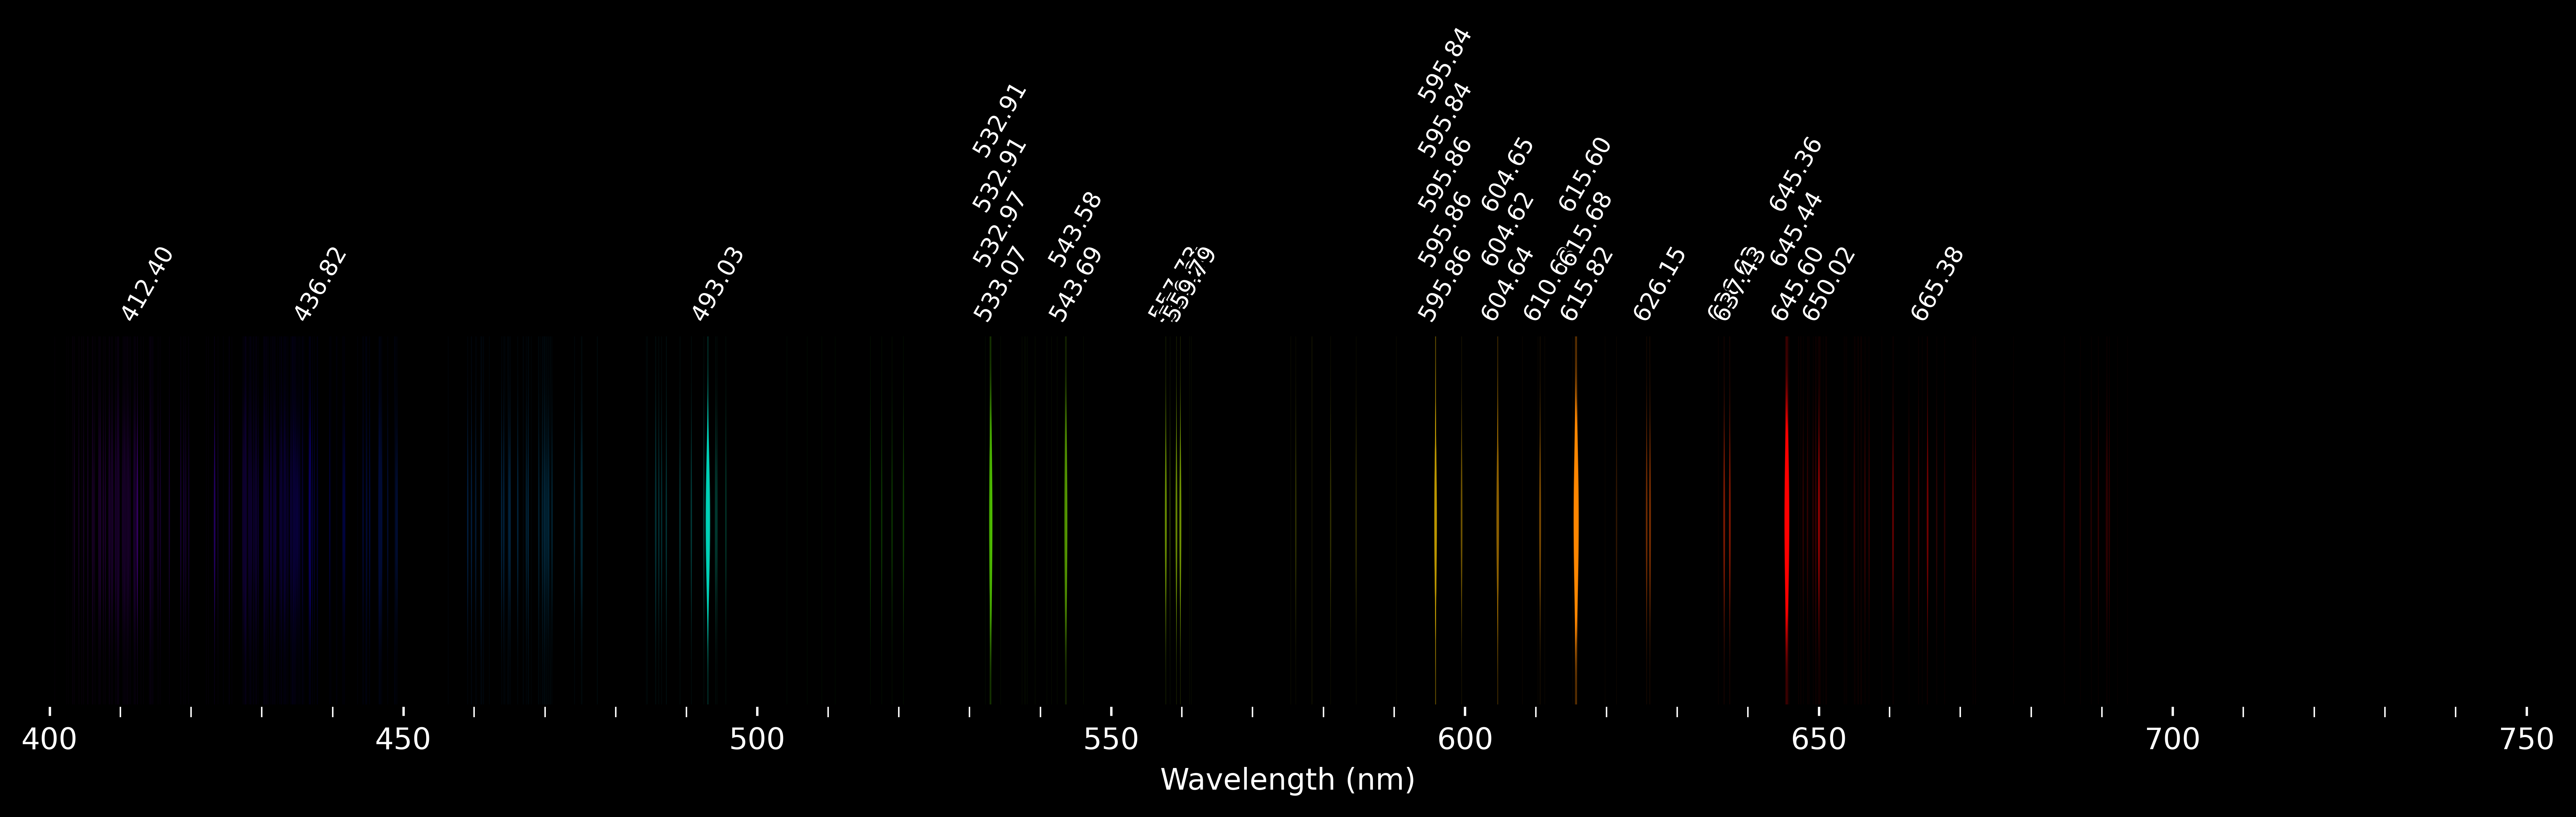

In [7]:
plot_spec(NIST_DF)